<a href="https://colab.research.google.com/github/ash3180/maths_for_ml_assingment/blob/main/my_folder/PCA/pca_maths.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance = None

    def fit(self, X):
        # Step 1: Standardize the data (subtract the mean)
        self.mean = np.mean(X, axis=0)
        X_centered = (X - self.mean)/X.std()

        # Step 2: Compute the covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Step 3: Compute the eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        # Step 4: Sort the eigenvalues and corresponding eigenvectors
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        # Step 5: Select the top n_components
        self.components = eigenvectors[:, :self.n_components]

        # Calculate explained variance
        total_variance = np.sum(eigenvalues)
        self.explained_variance = eigenvalues[:self.n_components] / total_variance

    def transform(self, X):
        # Step 6: Project the data onto the selected components
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def plot_explained_variance(self):
        # Create labels for each principal component
        labels = [f'PCA{i+1}' for i in range(self.n_components)]

        # Create a bar plot for explained variance
        plt.figure(figsize=(8, 6))
        plt.bar(range(1, self.n_components + 1), self.explained_variance, alpha=0.7, align='center', color='blue', tick_label=labels)
        plt.xlabel('Principal Component')
        plt.ylabel('Explained Variance Ratio')
        plt.title('Explained Variance by Principal Components')
        plt.show()

Explained Variance (%):
 [np.float64(55.406), np.float64(25.223), np.float64(11.137), np.float64(5.298), np.float64(0.641), np.float64(0.626), np.float64(0.511), np.float64(0.441), np.float64(0.401), np.float64(0.317)]
[ 55.40558853  80.62880947  91.76600786  97.06422186  97.70498137
  98.3305384   98.84121282  99.28231099  99.68334777 100.        ]
4


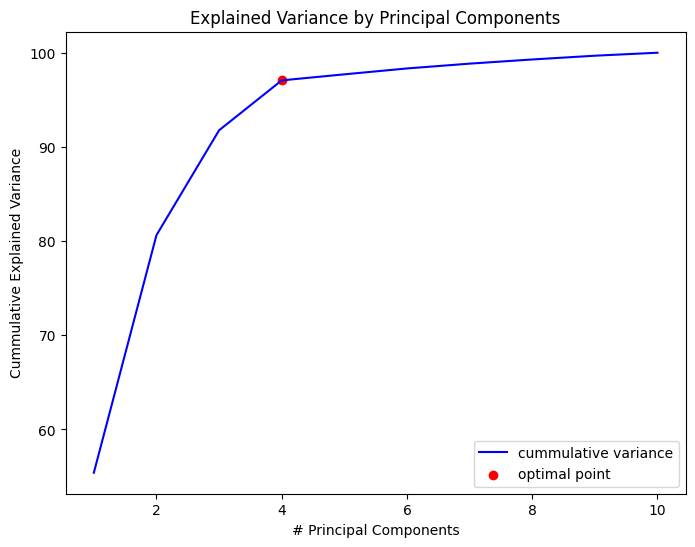

In [3]:
# Example usage
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    import numpy as np

    # create simulated data for analysis
    np.random.seed(42)
    # Generate a low-dimensional signal
    low_dim_data = np.random.randn(100, 4)

    # Create a random projection matrix to project into higher dimensions
    projection_matrix = np.random.randn(4, 10)

    # Project the low-dimensional data to higher dimensions
    high_dim_data = np.dot(low_dim_data, projection_matrix)

    # Add some noise to the high-dimensional data
    noise = np.random.normal(loc=0, scale=0.5, size=(100, 10))
    data_with_noise = high_dim_data + noise

    X = data_with_noise

    # Apply PCA
    pca = PCA(n_components=10)
    pca.fit(X)
    X_transformed = pca.transform(X)

    # Print the results
    # print("Mean:\n", pca.mean)
    # print("Components (Eigenvectors):\n", pca.components)
    explained_variance = [round(v,3) for v in pca.explained_variance*100]
    print("Explained Variance (%):\n", explained_variance)
    # print("Transformed Data (first 5 samples):\n", X_transformed[:5])

    # Plot explained variance
    # pca.plot_explained_variance()

    # create a array with the cumulative variance of each principal component
    cum_sum = np.cumsum(pca.explained_variance*100)
    print(cum_sum)
    d = np.argmax(cum_sum >= 95.0) + 1
    print(d)

    # create a scree plot to observe how many dimensions add up to 95% of the total variance
    plt.figure(figsize=(8, 6))
    plt.plot(range(1,11), cum_sum, c='blue')
    plt.scatter(d, cum_sum[d-1], c="red")
    plt.legend(['cummulative variance', 'optimal point'])
    plt.xlabel('# Principal Components')
    plt.ylabel('Cummulative Explained Variance')
    plt.title('Explained Variance by Principal Components')
    plt.show()